## Local deploying and serving 
Servir et interroger des modèles localement est très simple et peut être effectué en ligne de commande. Si vous souhaitez simplement servir le dernier modèle, vous pouvez le faire en utilisant l'ID du run .

Avant de commencer, accédez à nouveau à l'interface utilisateur de MLFlow et cliquez sur l'expérience scikit_learn_experiment. Choisissez une exécution et copiez l'ID de l'exécution. N'oubliez pas non plus le nom du modèle avec lequel vous avez enregistré le modèle, qui devrait être log_reg_model. 


In [11]:
import pandas as pd
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score,confusion_matrix
import numpy as np
import subprocess
import json

Tout d'abord, vous devez remplacer votre répertoire par un répertoire contenant le dossier mlruns avec toutes vos expériences. Ensuite, vous avez besoin de deux choses : l'ID du run de votre modèle et le nom de votre modèle. 

Une fois vous aurez ces information, exécutez cette commande:

> mlflow models serve --model-uri runs:/YOUR_MODEL_RUN/YOUR_MODEL_NAME -p 1235

MLFlow devrait commencer à construire immédiatement un nouvel environnement conda qu'il utilisera pour servir localement. Dans cet environnement, il installe des packages de base et des packages spécifiques que le modèle doit pouvoir s'exécuter.

notre modèle est servi sur : http://localhost:1235/ 

### Interroger le modèle 

Vous êtes maintenant prêt à interroger le modèle avec des données et à recevoir des prédictions. C'est là qu'intervient le module subprocess (ou requests). Tout d'abord, chargeons à nouveau notre dataframe. Exécutez le code suivant : 

#### Interrogation en utilisant subprocess

In [12]:
df = pd.read_csv("data/creditcard.csv")

In [13]:
# Prepare data in MLflow 2.0 format with dataframe_split wrapper
data_dict = df.iloc[:80].drop(["Time", "Class"], axis=1).to_dict(orient="split")
input_json = json.dumps({"dataframe_split": data_dict})

# nous allons extraire 80 valeur pour interroger le modèle avec

In [14]:
# Execute the curl command and capture both stdout and stderr
proc = subprocess.run(["curl", "-X", "POST", "-H", "Content-Type:application/json",
"--data", input_json, "http://127.0.0.1:1235/invocations"],
stdout=subprocess.PIPE, stderr=subprocess.PIPE, encoding='utf-8')

# Print the output for debugging
print("STDOUT:", proc.stdout)
print("STDERR:", proc.stderr)
print("Return code:", proc.returncode)

STDOUT: {"predictions": [1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]}
STDERR:   % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 44913  100   257  100 44656  18139  3078k --:--:-- --:--:-- --:--:-- 3132k

Return code: 0


In [15]:
output = proc.stdout

# Check if output is empty or invalid
if not output or output.strip() == "":
    print("ERROR: Empty response from server!")
    print("Make sure the MLflow server is running with:")
    print("mlflow models serve --model-uri runs:/YOUR_RUN_ID/log_reg_model -p 1235")
else:
    try:
        result = json.loads(output)
        print("Predictions:", result)
        # Convert predictions to DataFrame for better visualization
        if "predictions" in result:
            df2 = pd.DataFrame({"predictions": result["predictions"]})
            display(df2)
    except json.JSONDecodeError as e:
        print(f"JSON parsing error: {e}")
        print(f"Received output: {output}")

Predictions: {'predictions': [1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]}


,predictions
0,1
1,0
2,1
3,1
4,1
...,...
75,0
76,1
77,1
78,0


#### Interrogation en utilisant requests 

In [16]:
import requests 

In [17]:
import requests

host = '127.0.0.1'
port = '1235'

url = f'http://{host}:{port}/invocations'

headers = {
    'Content-Type': 'application/json',
}
r = requests.post(url=url, headers=headers, data=input_json)

print(f'Predictions: {r.text}')

Predictions: {"predictions": [1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0]}


ce que nous avons fait en haut (subprocess ou request) est équivalent à exécuter la commande ci-dessous sur l'invité de commande:

> curl -X POST -H "Content-Type:application/json;
format=pandas-split"
–data "CONTENT_OF_INPUT_JSON"
"http://127.0.0.1:1235/invocations"

Le cœur du problème est que si vous exécutez cela en ligne de commande, coller les données au format JSON peut devenir très compliqué car il y a tellement de colonnes. C'est pourquoi nous avons choisi d'utiliser subprocess ou requests car il est plus facile de transmettre directement le JSON lui-même en utilisant un nom de variable, input_json dans ce cas, pour contenir le contenu du JSON. 

#### Batch querying 

Malheureusement, il y a un maximum d'enregistrements qu'on peut envoyer pour la prédiction (presque 80).

Afin de remédier à ce problème, nous pouvons essayer de batcher nos données et faire une prédiction à chaque batch de données.

nous allons refaire la même chose avec scaling.

In [18]:
normal = df[df.Class == 0].sample(frac=0.5, random_state=2020).reset_index(drop=True)
anomaly = df[df.Class == 1]
normal_train, normal_test = train_test_split(normal,
test_size = 0.2, random_state = 2020)
anomaly_train, anomaly_test = train_test_split(anomaly, test_size = 0.2, random_state = 2020)
scaler = StandardScaler()
scaler.fit(pd.concat((normal, anomaly)).drop(["Time", "Class"],
axis=1))
test = df.iloc[:8000]
true = test.Class
test = scaler.transform(test.drop(["Time", "Class"], axis=1))
preds = []
batch_size = 80
for f in range(100):
    # Use MLflow 2.0 format with dataframe_split
    sample_dict = pd.DataFrame(test[f*batch_size:(f+1)*batch_size]).to_dict(orient="split")
    sample = json.dumps({"dataframe_split": sample_dict})
    proc = subprocess.run(["curl", "-X", "POST", "-H", "Content-Type:application/json", "--data", sample, "http://127.0.0.1:1235/invocations"], stdout=subprocess.PIPE, encoding='utf-8')
    output = proc.stdout
    resp = json.loads(output)
    preds = np.concatenate((preds, resp["predictions"]))
eval_acc = accuracy_score(true, preds)
eval_auc = roc_auc_score(true, preds)
print("Eval Acc", eval_acc)
print("Eval AUC", eval_auc)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49308  100   257  100 49051  52310  9749k --:--:-- --:--:-- --:--:-- 11.7M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49167  100   257  100 48910  68679  12.4M --:--:-- --:--:-- --:--:-- 15.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49075  100   257  100 48818  71868  13.0M --:--:-- --:--:-- --:--:-- 15.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 49203  100   257  100 48946  72496  13.1M --:--:-- --:--:-- --:--:-- 15.6M
  % Total    % Received % Xferd  Average Speed   Tim

Eval Acc 0.999625
Eval AUC 0.9798746081504702


100 48910  100   257  100 48653  65829  11.8M --:--:-- --:--:-- --:--:-- 15.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48882  100   257  100 48625  55893  10.0M --:--:-- --:--:-- --:--:-- 11.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48908  100   257  100 48651  78258  14.1M --:--:-- --:--:-- --:--:-- 15.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48874  100   257  100 48617  74535  13.4M --:--:-- --:--:-- --:--:-- 15.5M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 48848  100   257  100 48591  83959  15.1M --:--:

Ici, vous sélectionnez les 8 000 premiers échantillons du dataframe. Étant donné que la taille du lot est de 80, vous avez 100 lots que vous transmettez au modèle 

Text(0.5, 1.0, 'Confusion Matrix')

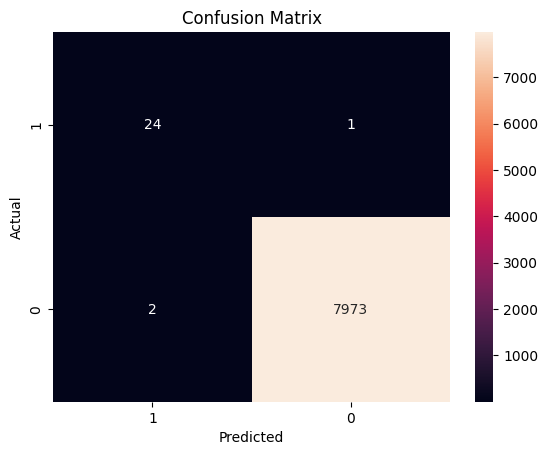

In [19]:
conf_matrix = confusion_matrix(true, preds)
ax = sns.heatmap(conf_matrix, annot=True,fmt='g')
ax.invert_xaxis()
ax.invert_yaxis()
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")